# Evaluación 2 - ID 1001371283
**Programación Científica 2026-1** · Universidad Nacional de Colombia

Este notebook contiene la solución completa para los 4 entregables de la rúbrica:
1. Capa Fourier y energía media.
2. Entrenamiento y reconstrucción (3 regímenes, 2 inicializaciones).
3. Comparación de inicializaciones y régimen difícil.
4. Compresión y umbral del 95%.

In [31]:
# =============================================
# 0. IMPORTS Y CARGA DE DATOS
# =============================================

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, jit
import warnings
warnings.filterwarnings('ignore')

# Cargar los datos
data = np.load('datos_1283.npz')
X = data['X']       # (24, 256)
y = data['y']       # (24,)
t = data['t']       # (256,)
meta = data['meta'] # (3,)

N = 256
K = 30
print(f"Señales cargadas: {X.shape}")
print(f"Etiquetas: {y.shape}")
print(f"Vector tiempo: {t.shape}")

Señales cargadas: (24, 256)
Etiquetas: (24,)
Vector tiempo: (256,)


## 1. Capa Fourier

Se construye la matriz $W_1$ de tamaño $(2K \times N)$ con senos y cosenos para las frecuencias $k=1,\dots,K$. Se usa el índice discreto $n = 0,\dots,N-1$ para que coincida con la definición de la DFT de NumPy.

Matriz W_fourier: (60, 256)
Error relativo vs FFT: 9.85e-16


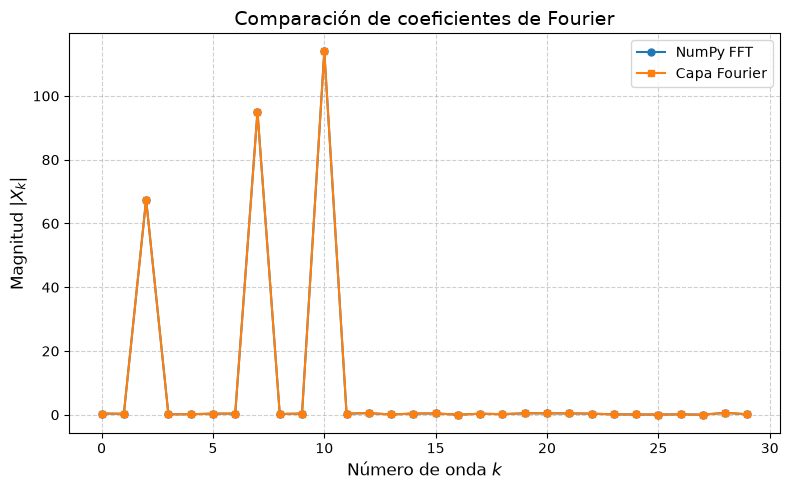


Energía media del dataset: 0.838


In [32]:
# =============================================
# 1. CONSTRUCCIÓN DE LA CAPA FOURIER
# =============================================

def construir_capa_fourier(N, K):
    """Matriz de senos y cosenos para k=1..K (sin normalizar)"""
    n = np.arange(N)
    W = np.zeros((2*K, N))
    for k in range(1, K+1):
        W[2*(k-1), :] = np.cos(2 * np.pi * k * n / N)
        W[2*(k-1)+1, :] = np.sin(2 * np.pi * k * n / N)
    return W

W_fourier = construir_capa_fourier(N, K)
print(f"Matriz W_fourier: {W_fourier.shape}")

# =============================================
# 1.1 VERIFICACIÓN CON np.fft
# =============================================

x_test = X[0]
z = W_fourier @ x_test
cos_coef = z[0::2]
sen_coef = z[1::2]
coef_complejo = cos_coef - 1j * sen_coef  # Relación: X[k] = cos - i*sen

fft_ref = np.fft.fft(x_test)[1:K+1]

error_fft = np.linalg.norm(np.abs(coef_complejo) - np.abs(fft_ref)) / np.linalg.norm(np.abs(fft_ref))
print(f"Error relativo vs FFT: {error_fft:.2e}")

# Gráfica de verificación
plt.figure(figsize=(8, 5))
plt.plot(np.abs(fft_ref), 'o-', label='NumPy FFT', markersize=5)
plt.plot(np.abs(coef_complejo), 's-', label='Capa Fourier', markersize=5)
plt.xlabel(r'Número de onda $k$', fontsize=12)
plt.ylabel(r'Magnitud $|X_k|$', fontsize=12)
plt.title('Comparación de coeficientes de Fourier', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# =============================================
# 1.2 ENERGÍA MEDIA DEL DATASET
# =============================================

energia_media = (X**2).mean()
print(f"\nEnergía media del dataset: {energia_media:.3f}")

## 2. Señales por régimen

El dataset contiene 8 señales por régimen:
- Régimen 0: baja frecuencia
- Régimen 1: media frecuencia (régimen difícil)
- Régimen 2: alta frecuencia

Se selecciona la primera señal de cada régimen para los experimentos.

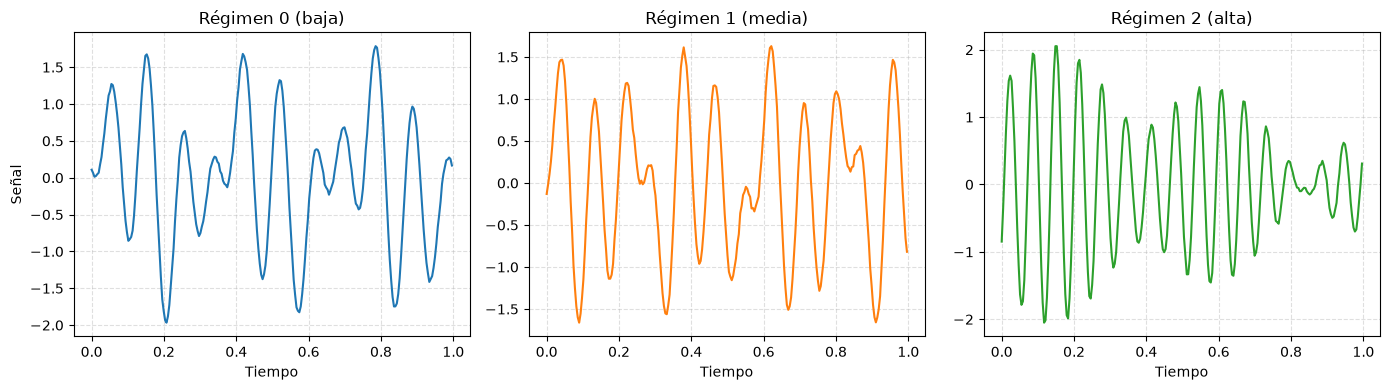

In [33]:
# =============================================
# 2. SEPARACIÓN POR RÉGIMENES
# =============================================

X0 = X[y == 0]  # Régimen 0 (baja)
X1 = X[y == 1]  # Régimen 1 (media)
X2 = X[y == 2]  # Régimen 2 (alta)

x_reg0, x_reg1, x_reg2 = X0[0], X1[0], X2[0]
señales = [x_reg0, x_reg1, x_reg2]
nombres = ['Régimen 0 (baja)', 'Régimen 1 (media)', 'Régimen 2 (alta)']
colores = ['C0', 'C1', 'C2']

# Gráfica de las 3 señales
plt.figure(figsize=(14, 4))
for i, (x, nombre, color) in enumerate(zip(señales, nombres, colores)):
    plt.subplot(1, 3, i+1)
    plt.plot(t, x, color=color)
    plt.title(nombre, fontsize=12)
    plt.xlabel('Tiempo')
    if i == 0:
        plt.ylabel('Señal')
    plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 3. Reconstrucción lineal directa

Usando solo la capa Fourier (sin entrenar), reconstruimos la señal para ver el efecto de truncar frecuencias y omitir el componente DC. Esto explica por qué la red neuronal debe aprender un sesgo.

Error relativo de reconstrucción lineal: 0.0471
Energía en frecuencias > k=30: 0.09%


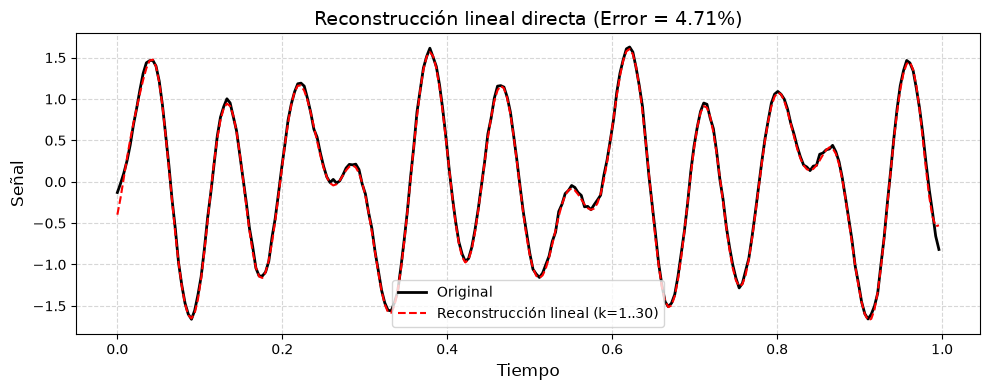

In [34]:
# =============================================
# 3. RECONSTRUCCIÓN LINEAL CON CAPA FOURIER
# =============================================

x_prueba = x_reg1  # Usamos el régimen 1 como ejemplo

z = W_fourier @ x_prueba
# Reconstrucción con factor 2/N (porque la base no está normalizada)
x_hat_lineal = (2.0 / N) * (W_fourier.T @ z)

error_lineal = np.linalg.norm(x_hat_lineal - x_prueba) / np.linalg.norm(x_prueba)
print(f"Error relativo de reconstrucción lineal: {error_lineal:.4f}")

# Análisis espectral para entender el error
fft_total = np.fft.fft(x_prueba)
energia_total = np.sum(np.abs(fft_total)**2)
energia_truncada = np.sum(np.abs(fft_total[31:N//2])**2)  # frecuencias > 30
print(f"Energía en frecuencias > k=30: {100 * energia_truncada / energia_total:.2f}%")

plt.figure(figsize=(10, 4))
plt.plot(t, x_prueba, 'k-', label='Original', linewidth=2)
plt.plot(t, x_hat_lineal, 'r--', label='Reconstrucción lineal (k=1..30)', linewidth=1.5)
plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Señal', fontsize=12)
plt.title(f'Reconstrucción lineal directa (Error = {error_lineal:.2%})', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. Arquitectura de la red

La red tiene dos capas:
1. Capa lineal $W_1$: $256 \to 60$ seguida de $\tanh$.
2. Capa lineal $W_2$: $60 \to 256$ (reconstrucción).

Se inicializa de dos formas:
- **Fourier:** $W_1$ fija como la matriz de Fourier, $W_2$ aleatoria.
- **Aleatoria:** $W_1$ y $W_2$ aleatorias.

La pérdida es el error cuadrático medio (MSE) entre la señal original y la reconstruida.

In [35]:
# =============================================
# 4. RED NEURONAL EN JAX
# =============================================

def red(W1, W2, x):
    h = jnp.tanh(W1 @ x)
    return W2 @ h

def mse_loss(W1, W2, x, objetivo):
    x_hat = red(W1, W2, x)
    return jnp.mean((x_hat - objetivo) ** 2)

# Gradientes
grad_loss = grad(mse_loss, argnums=(0, 1))

# Función de entrenamiento
def entrenar(W1_init, W2_init, x, lr=0.05, steps=3000, log_every=50):
    W1 = W1_init
    W2 = W2_init
    losses = []
    errors = []
    
    for i in range(steps):
        g1, g2 = grad_loss(W1, W2, x, x)
        W1 = W1 - lr * g1
        W2 = W2 - lr * g2
        
        if i % log_every == 0:
            x_hat = red(W1, W2, x)
            loss = float(mse_loss(W1, W2, x, x))
            error = float(jnp.linalg.norm(x_hat - x) / jnp.linalg.norm(x))
            losses.append(loss)
            errors.append(error)
    
    x_hat_final = np.array(red(W1, W2, x))
    return losses, errors, x_hat_final

# Inicializaciones
key = jax.random.PRNGKey(0)
W1_fourier = jnp.array(W_fourier)
W2_fourier = jnp.array(np.random.normal(0, 0.01, (N, 2*K)))
W1_alea = jnp.array(np.random.normal(0, 1.0, (2*K, N)))
W2_alea = jnp.array(np.random.normal(0, 0.01, (N, 2*K)))

print("Inicializaciones listas.")
print(f"W1_fourier shape: {W1_fourier.shape}")
print(f"W1_alea shape: {W1_alea.shape}")

Inicializaciones listas.
W1_fourier shape: (60, 256)
W1_alea shape: (60, 256)


## 5. Entrenamiento

Se entrena la red para las 3 señales de prueba (una por régimen), con ambas inicializaciones (Fourier y aleatoria). Se guardan las pérdidas y errores cada 50 iteraciones.

In [36]:
# =============================================
# 5. ENTRENAMIENTO
# =============================================

lr = 0.05
steps = 3000
log_every = 50

resultados = {}  # (reg_idx, init) -> (losses, errors, x_hat)

for idx, (x, nombre) in enumerate(zip(señales, nombres)):
    x_jax = jnp.array(x)
    print(f"\nEntrenando {nombre}...")
    
    # Fourier
    losses_f, errors_f, x_hat_f = entrenar(W1_fourier, W2_fourier, x_jax, lr, steps, log_every)
    resultados[(idx, 'fourier')] = (losses_f, errors_f, x_hat_f)
    
    # Aleatoria
    losses_a, errors_a, x_hat_a = entrenar(W1_alea, W2_alea, x_jax, lr, steps, log_every)
    resultados[(idx, 'aleatoria')] = (losses_a, errors_a, x_hat_a)

print("\n¡Entrenamiento completado!")


Entrenando Régimen 0 (baja)...

Entrenando Régimen 1 (media)...

Entrenando Régimen 2 (alta)...

¡Entrenamiento completado!


## 6. Reconstrucción final

Para cada régimen, se muestra la señal original junto a las reconstrucciones obtenidas con ambas inicializaciones.

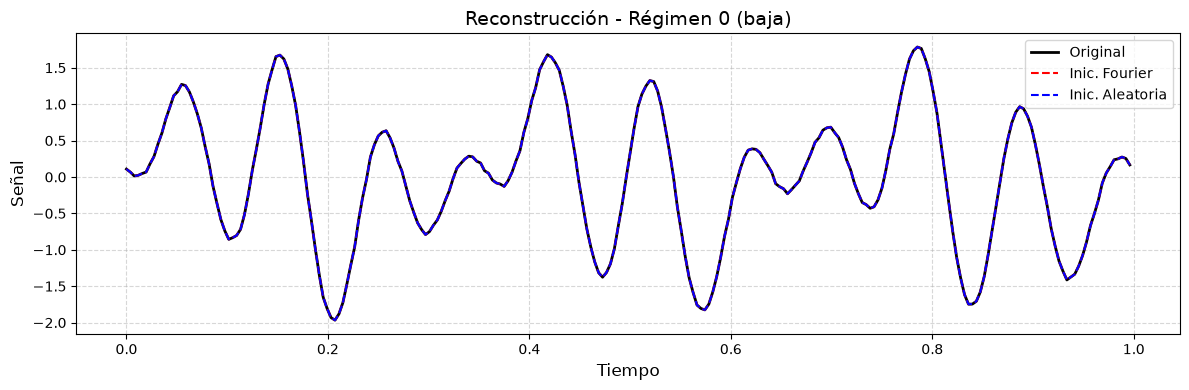

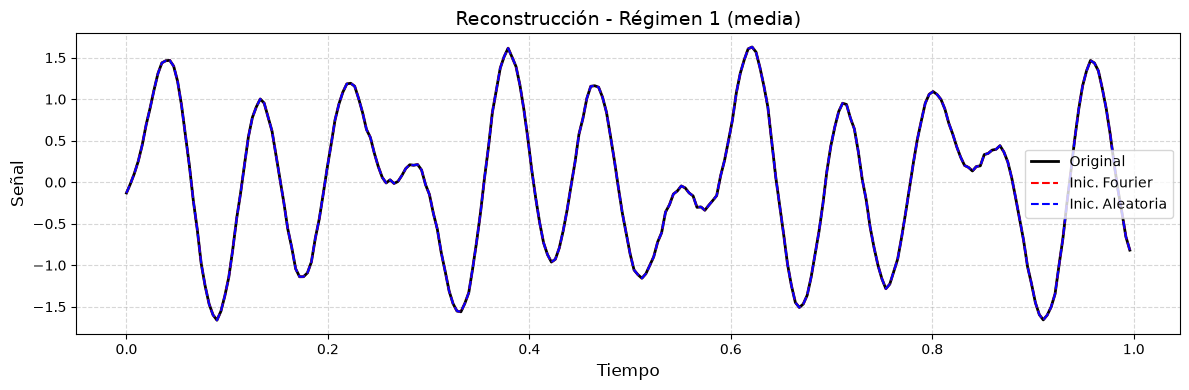

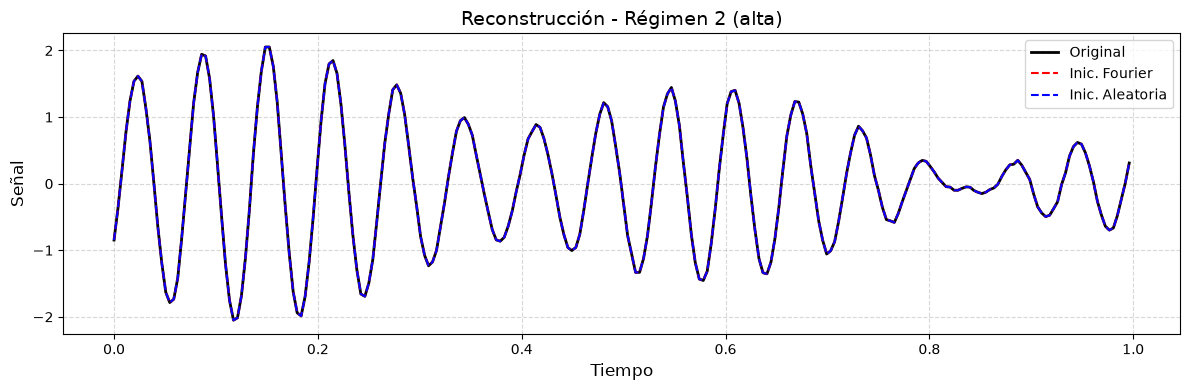

In [37]:
# =============================================
# 6. GRÁFICAS DE RECONSTRUCCIÓN
# =============================================

for idx, nombre in enumerate(nombres):
    _, _, x_hat_f = resultados[(idx, 'fourier')]
    _, _, x_hat_a = resultados[(idx, 'aleatoria')]
    x_orig = señales[idx]
    
    plt.figure(figsize=(12, 4))
    plt.plot(t, x_orig, 'k-', label='Original', linewidth=2)
    plt.plot(t, x_hat_f, 'r--', label='Inic. Fourier', linewidth=1.5)
    plt.plot(t, x_hat_a, 'b--', label='Inic. Aleatoria', linewidth=1.5)
    plt.xlabel('Tiempo', fontsize=12)
    plt.ylabel('Señal', fontsize=12)
    plt.title(f'Reconstrucción - {nombre}', fontsize=14)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

## 7. Comparación de inicializaciones

Se comparan las curvas de pérdida y error relativo para ambas inicializaciones. Se mide el número de iteraciones necesarias para que el error relativo baje de 0.1. El régimen 1 (media frecuencia) es el régimen difícil según el enunciado.

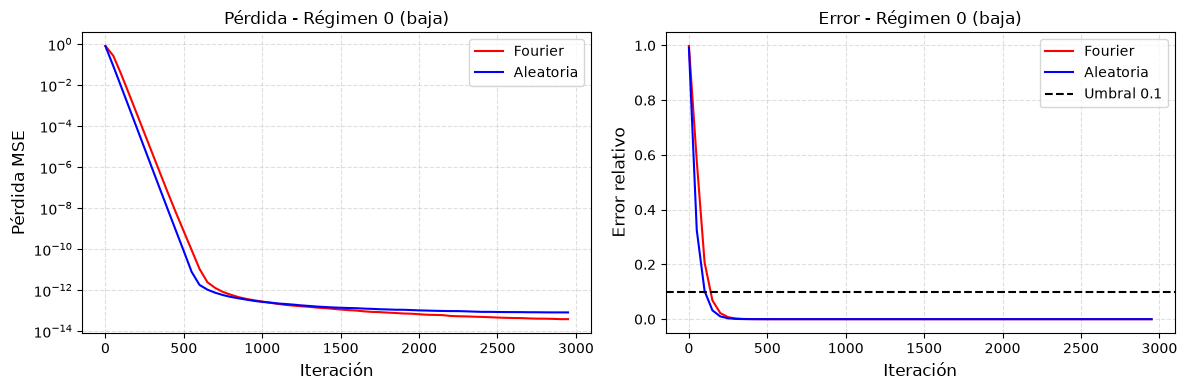

Régimen 0 (baja): Fourier -> 150 iters, Aleatoria -> 150 iters


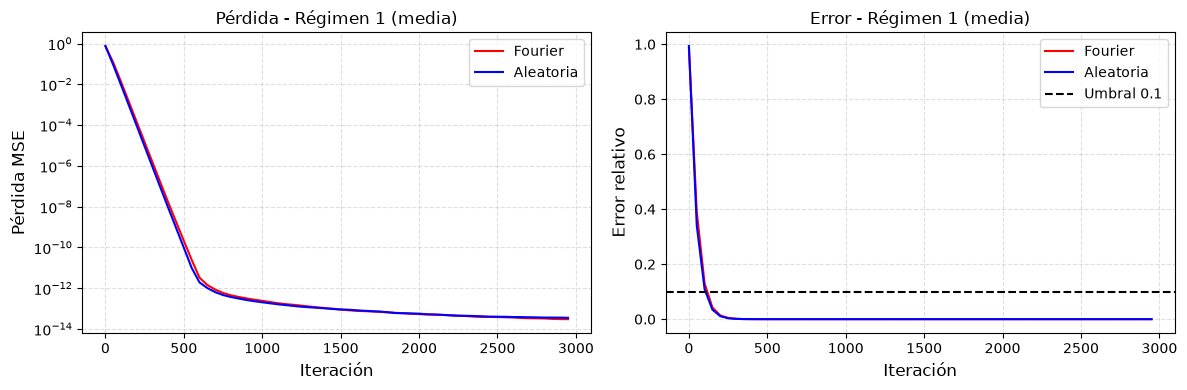

Régimen 1 (media): Fourier -> 150 iters, Aleatoria -> 150 iters


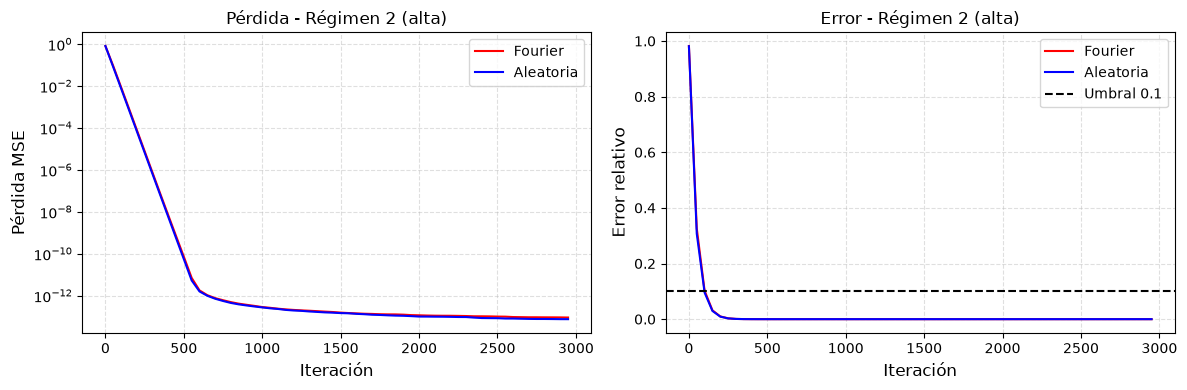

Régimen 2 (alta): Fourier -> 150 iters, Aleatoria -> 100 iters

--- Análisis del régimen difícil (Régimen 1) ---


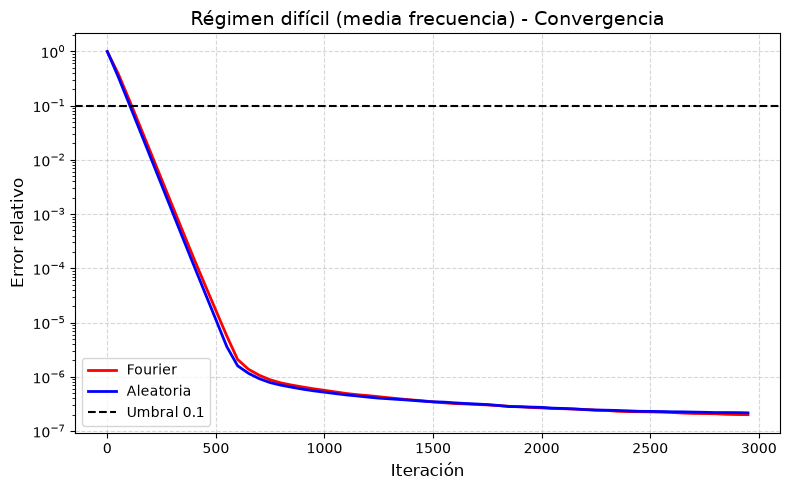

In [38]:
# =============================================
# 7. CURVAS DE PÉRDIDA Y ERROR
# =============================================

iter_plot = np.arange(0, steps, log_every)

for idx, nombre in enumerate(nombres):
    losses_f, errors_f, _ = resultados[(idx, 'fourier')]
    losses_a, errors_a, _ = resultados[(idx, 'aleatoria')]
    
    # Pérdida
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.semilogy(iter_plot, losses_f, 'r-', label='Fourier')
    plt.semilogy(iter_plot, losses_a, 'b-', label='Aleatoria')
    plt.xlabel('Iteración', fontsize=12)
    plt.ylabel('Pérdida MSE', fontsize=12)
    plt.title(f'Pérdida - {nombre}', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    
    # Error relativo
    plt.subplot(1, 2, 2)
    plt.plot(iter_plot, errors_f, 'r-', label='Fourier')
    plt.plot(iter_plot, errors_a, 'b-', label='Aleatoria')
    plt.axhline(y=0.1, color='k', linestyle='--', label='Umbral 0.1')
    plt.xlabel('Iteración', fontsize=12)
    plt.ylabel('Error relativo', fontsize=12)
    plt.title(f'Error - {nombre}', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()
    
    # Medición de iteraciones
    idx_f = np.argmax(np.array(errors_f) < 0.1) if any(np.array(errors_f) < 0.1) else -1
    idx_a = np.argmax(np.array(errors_a) < 0.1) if any(np.array(errors_a) < 0.1) else -1
    it_f = iter_plot[idx_f] if idx_f != -1 else 'Nunca'
    it_a = iter_plot[idx_a] if idx_a != -1 else 'Nunca'
    print(f"{nombre}: Fourier -> {it_f} iters, Aleatoria -> {it_a} iters")

# =============================================
# 7.1 RÉGIMEN DIFÍCIL (Régimen 1)
# =============================================

print("\n--- Análisis del régimen difícil (Régimen 1) ---")
idx_dificil = 1
_, errors_f, _ = resultados[(idx_dificil, 'fourier')]
_, errors_a, _ = resultados[(idx_dificil, 'aleatoria')]

plt.figure(figsize=(8, 5))
plt.semilogy(iter_plot, errors_f, 'r-', linewidth=2, label='Fourier')
plt.semilogy(iter_plot, errors_a, 'b-', linewidth=2, label='Aleatoria')
plt.axhline(y=0.1, color='k', linestyle='--', label='Umbral 0.1')
plt.xlabel('Iteración', fontsize=12)
plt.ylabel('Error relativo', fontsize=12)
plt.title('Régimen difícil (media frecuencia) - Convergencia', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Compresión

Se toman los coeficientes de Fourier de la señal del régimen 1, se ordenan por magnitud y se reconstruye la señal conservando solo los $k$ coeficientes más grandes. Se busca el número mínimo de coeficientes para alcanzar el 95% de la energía total.

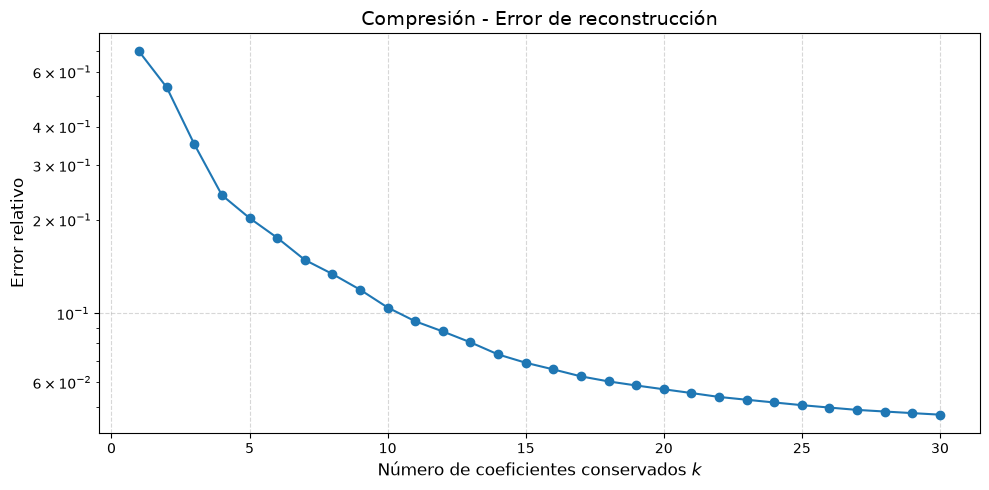

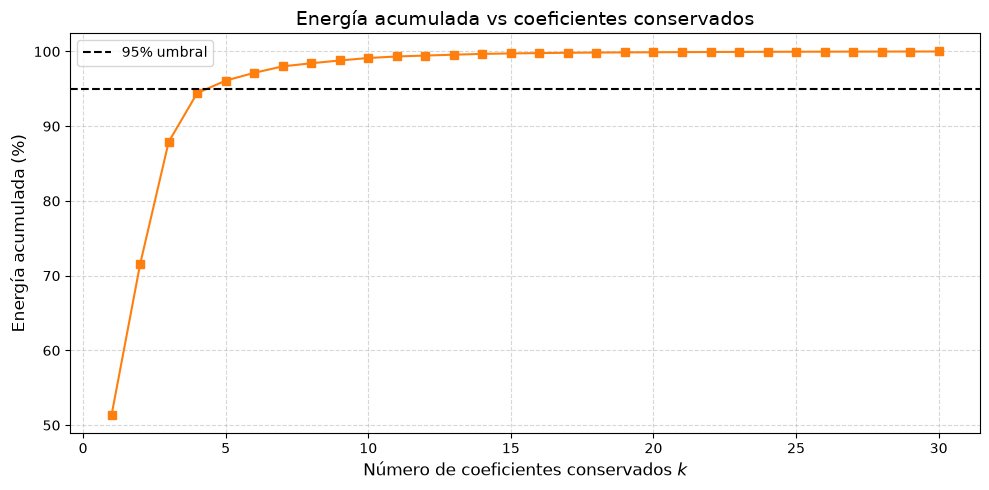

Energía total: 25006.544
Umbral 95%: 23756.217
Coeficientes necesarios para 95% de energía: 5
Energía acumulada con 5 coefs: 24031.804 (96.1%)


In [39]:
# =============================================
# 8. COMPRESIÓN
# =============================================

x_comp = x_reg1

# Coeficientes complejos (k=1..K)
z_comp = W_fourier @ x_comp
cos_c = z_comp[0::2]
sen_c = z_comp[1::2]
coef_c = cos_c - 1j * sen_c

# Ordenar por magnitud
magnitudes = np.abs(coef_c)
idx_sort = np.argsort(magnitudes)[::-1]

# Energías
energia_total = np.sum(magnitudes**2)
umbral_95 = 0.95 * energia_total

ks = np.arange(1, K+1)
errores = []
energias_acum = []

for k in ks:
    coef_k = np.zeros(K, dtype=complex)
    coef_k[idx_sort[:k]] = coef_c[idx_sort[:k]]
    
    # Reconstruir señal linealmente
    coef_real = np.zeros(2*K)
    for i in range(K):
        coef_real[2*i] = np.real(coef_k[i])
        coef_real[2*i+1] = -np.imag(coef_k[i])
    
    x_hat_k = (2.0 / N) * (W_fourier.T @ coef_real)
    
    error_k = np.linalg.norm(x_hat_k - x_comp) / np.linalg.norm(x_comp)
    errores.append(error_k)
    
    energia_acum = np.sum(magnitudes[idx_sort[:k]]**2)
    energias_acum.append(energia_acum)

# Gráfica error
plt.figure(figsize=(10, 5))
plt.semilogy(ks, errores, 'o-', color='C0', markersize=6)
plt.xlabel('Número de coeficientes conservados $k$', fontsize=12)
plt.ylabel('Error relativo', fontsize=12)
plt.title('Compresión - Error de reconstrucción', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Gráfica energía acumulada
plt.figure(figsize=(10, 5))
plt.plot(ks, 100 * np.array(energias_acum) / energia_total, 's-', color='C1', markersize=6)
plt.axhline(y=95, color='k', linestyle='--', label='95% umbral')
plt.xlabel('Número de coeficientes conservados $k$', fontsize=12)
plt.ylabel('Energía acumulada (%)', fontsize=12)
plt.title('Energía acumulada vs coeficientes conservados', fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Resultados
idx_95 = np.argmax(np.array(energias_acum) >= umbral_95) + 1
print(f"Energía total: {energia_total:.3f}")
print(f"Umbral 95%: {umbral_95:.3f}")
print(f"Coeficientes necesarios para 95% de energía: {idx_95}")
print(f"Energía acumulada con {idx_95} coefs: {energias_acum[idx_95-1]:.3f} ({100*energias_acum[idx_95-1]/energia_total:.1f}%)")